## Intended Learning Outcome

1. Perform descriptive and correlation analysis to to analyze the dataset.
2. Interpret the results of descriptive and correlation analysis

## Resources
- Personal Computer
- Jupyter Notebook
- Internet Connection

## Instruction

1. Gather a dataset regarding your identified problem for the ASEAN Data Science Explorer. You may look at previous ADSE Competitions for Problem References. Make sure that the dataset includes multiple variables.

Enter Dataset description here

2. Load the dataset into pandas dataframe.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [2]:
data_raw = pd.read_csv('API_Download_DS2_en_csv_v2_19397.csv', header=2)

3. Prepare the data by applying appropriate data preprocessing techniques. 

In [ ]:
data_raw.dropna(axis=1, how='all', inplace=True)
data_raw.columns = [str(c).strip() for c in data_raw.columns]


needed_data = {
    'Life expectancy at birth, total (years)'             : 'Life_Expectancy',
    'School enrollment, secondary (% gross)'              : 'School_Enrollment',
    'Mortality rate, under-5 (per 1,000 live births)'     : 'Child_Mortality',
    'Fertility rate, total (births per woman)'            : 'Fertility_Rate',
    'Birth rate, crude (per 1,000 people)'                : 'Birth_Rate',
    'Death rate, crude (per 1,000 people)'                : 'Death_Rate',
    'Current health expenditure per capita (current US$)' : 'Health_Expenditure',
    'Urban population (% of total population)'            : 'Urban_Population',
}

selected_data = list(needed_data.values())

data_filtered = data_raw[data_raw['Indicator Name'].isin(needed_data.keys())]

year_columns = [str(y) for y in range(2000, 2021)] 
columns_to_keep = ['Country Name', 'Country Code', 'Indicator Name'] + year_columns
data_filtered = data_filtered[columns_to_keep]

data_long = data_filtered.melt(
    id_vars=['Country Name', 'Country Code', 'Indicator Name'],
    value_vars=year_columns,
    var_name='Year',
    value_name='Value'
)

data_long['Year'] = data_long['Year'].astype(int)

data_long['Indicator_Short'] = data_long['Indicator Name'].map(needed_data)

data = data_long.pivot_table(
    index=['Country Name', 'Country Code', 'Year'],
    columns='Indicator_Short',
    values='Value'
).reset_index()
data.columns.name = None

data = data.sort_values(['Country Name', 'Year'])
data['School_Enrollment'] = (
    data.groupby('Country Name')['School_Enrollment']
    .transform(lambda x: x.interpolate(method='linear', limit_direction='both'))
)
data = data.reset_index(drop=True)


print(data.isna().sum())

data.dropna(subset=selected_data, how='all', inplace=True)

data

Country Name          0
Country Code          0
Year                  0
Birth_Rate            0
Child_Mortality       0
Death_Rate            0
Fertility_Rate        0
Health_Expenditure    0
Life_Expectancy       0
School_Enrollment     0
Urban_Population      0
dtype: int64


,Country Name,Country Code,Year,Birth_Rate,Child_Mortality,Death_Rate,Fertility_Rate,Health_Expenditure,Life_Expectancy,School_Enrollment,Urban_Population
0,Indonesia,IDN,2000,21.688,51.9,7.431,2.503,15.391487,66.292,55.597630,41.986154
1,Indonesia,IDN,2001,21.386,49.6,7.391,2.466,16.873442,66.583,56.227322,42.901890
2,Indonesia,IDN,2002,21.107,47.3,7.315,2.436,18.978485,66.954,57.646599,43.782407
3,Indonesia,IDN,2003,20.834,45.2,7.336,2.410,25.510656,67.134,60.724468,44.630176
4,Indonesia,IDN,2004,20.796,49.1,8.097,2.415,25.982700,65.521,62.975868,45.447674
...,...,...,...,...,...,...,...,...,...,...,...
121,Viet Nam,VNM,2016,17.313,21.8,6.195,2.000,133.196014,73.984,90.158335,32.847619
122,Viet Nam,VNM,2017,16.764,21.5,6.238,1.985,147.514252,74.026,91.072520,33.362596
123,Viet Nam,VNM,2018,15.438,21.4,6.263,1.880,161.978714,74.100,92.837771,33.941023
124,Viet Nam,VNM,2019,15.513,21.2,6.300,1.943,171.152969,74.211,94.654622,34.623913


4. Analyze the data using descriptive analysis.

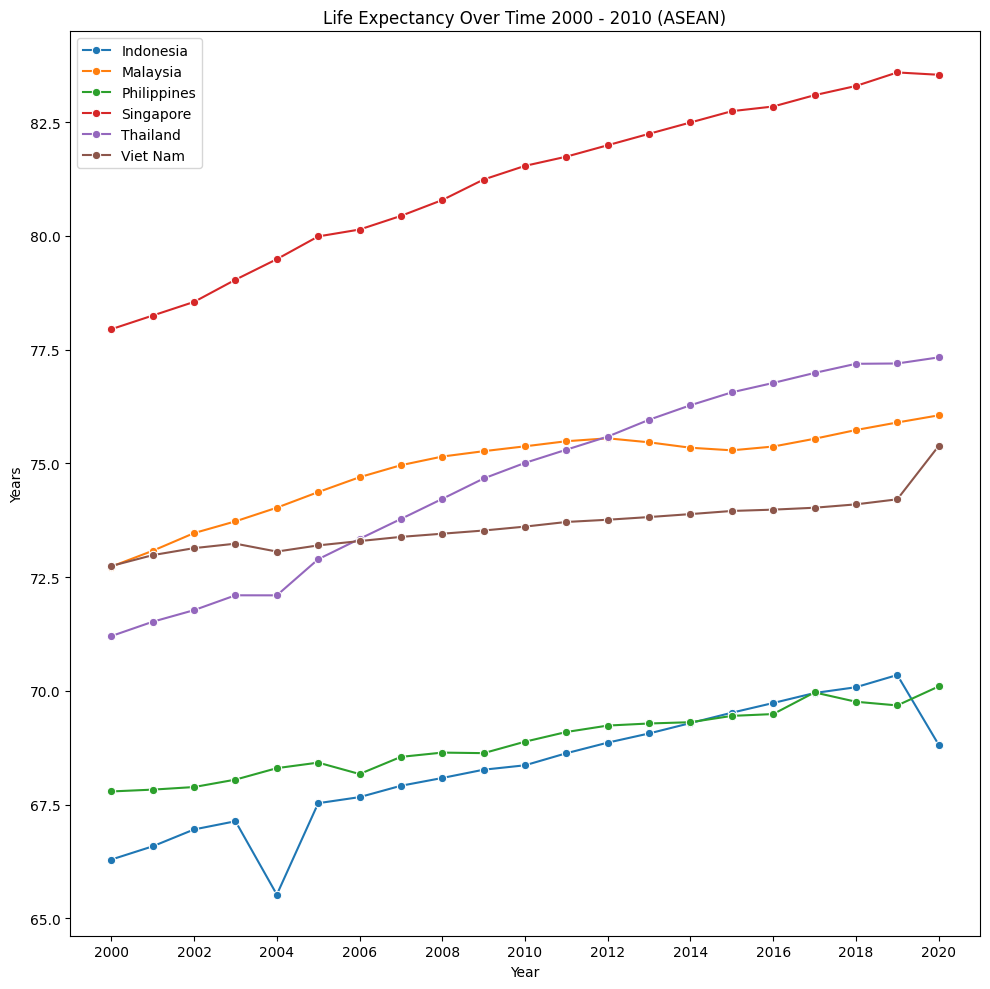

In [17]:
plt.figure(figsize=(10,10))
sns.lineplot(data=data, x='Year', y='Life_Expectancy', hue='Country Name', marker='o')
plt.xticks(range(2000, 2021, 2))
plt.title('Life Expectancy Over Time 2000 - 2010 (ASEAN)')
plt.ylabel('Years')
plt.xlabel('Year')
plt.legend()
plt.tight_layout()
plt.show()

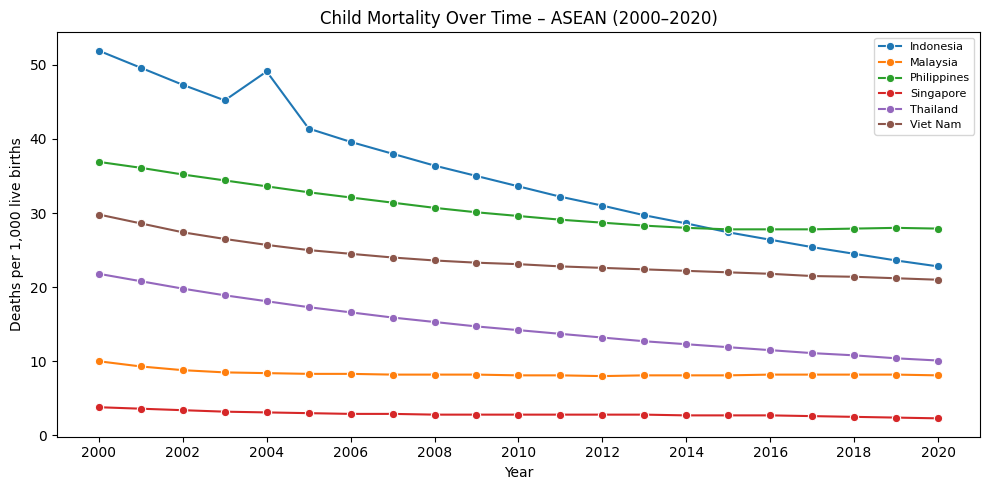

In [11]:
plt.figure(figsize=(10, 5))
sns.lineplot(data=data, x='Year', y='Child_Mortality', hue='Country Name', marker='o')
plt.xticks(range(2000, 2021, 2))
plt.title('Child Mortality Over Time – ASEAN (2000–2020)')
plt.ylabel('Deaths per 1,000 live births')
plt.xlabel('Year')
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

5. Perform correlation analysis.

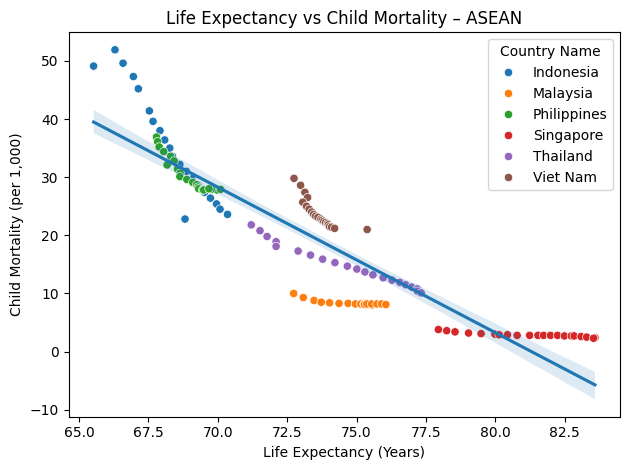

In [16]:
sns.scatterplot(data=data, x='Life_Expectancy', y='Child_Mortality',
                hue='Country Name')
sns.regplot(data=data, x='Life_Expectancy', y='Child_Mortality',
            scatter=False)
plt.title('Life Expectancy vs Child Mortality – ASEAN')
plt.xlabel('Life Expectancy (Years)')
plt.ylabel('Child Mortality (per 1,000)')
plt.tight_layout()

6. Interpret the results based on the descriptive and correlation analysis.

#### Descriptive Analysis
From the created line graphs, it shows that the life expectancy accross the ASEAN countries that are selected generally increased over the years with the exception for Indonesia in the year between 2018 and 2020 where covid was introduced to the world and pandemic started. This indicates that living conditions, general health care, and quality of life has overall improvements. At the same time, child mortality rates showed a downward trend, indicating that there are better health care/services and child health interventions. 

#### Correlation Analysis
From the created scatter plot and regression line, there is a negative relationship between life expectancy and child mortality where countries that has a higher life expectancy generally tend to have a lower child mortality rate. This inverse correlation shows that as a nation's health care systems and overall quality of life improve, life expectancy increases and early-age deaths decreases. 

Overall, the given results shows that there is a strong relationship or connection between these two indicators which emphasizes the importance of a nation's health care system and overall living conditions or quality of life. 